In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

# Load the dataset
df = pd.read_csv('store_sales (2).csv')

# Display first few rows to understand the structure
df.head()

,CustomerID,Age,Gender,Category,ItemPurchased,Amount,Season,PaymentMethod,ItemRating,DiscountApplied(%),PreviousPurchases
0,1,58,Female,Accessories,Handbag,115.50,Autumn,Card,3.5,18,4
1,2,40,Male,Mens Clothing,Shirt,103.43,Spring,Card,4.1,13,4
2,3,66,Female,Sports,Football,35.45,Spring,Card,3.3,11,3
3,4,39,Female,Accessories,Handbag,153.31,Spring,Card,4.4,13,4
4,5,23,Female,Home,Curtains,151.43,Winter,Card,4.1,20,10


In [2]:
# Check for missing values in each column
print("Missing values per column:\n", df.isnull().sum())

# Check for duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())

# Check data types and general info
print("\nDataset Info:")
df.info()

# Summary statistics for numerical columns
df.describe()

Missing values per column:
 CustomerID            0
Age                   0
Gender                0
Category              0
ItemPurchased         0
Amount                0
Season                0
PaymentMethod         0
ItemRating            0
DiscountApplied(%)    0
PreviousPurchases     0
dtype: int64

Number of duplicate rows: 0

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Gender              5000 non-null   object 
 3   Category            5000 non-null   object 
 4   ItemPurchased       5000 non-null   object 
 5   Amount              5000 non-null   float64
 6   Season              5000 non-null   object 
 7   PaymentMethod       5000 non-null   object 
 8   ItemRating          5000 non-null   float64
 9   

,CustomerID,Age,Amount,ItemRating,DiscountApplied(%),PreviousPurchases
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,45.224800,285.090522,3.784160,14.983600,5.008800
std,1443.520003,14.564995,551.454382,0.681796,5.988063,2.194285
min,1.000000,20.000000,5.080000,1.100000,0.000000,0.000000
25%,1250.750000,33.000000,70.547500,3.300000,11.000000,3.000000
50%,2500.500000,45.000000,122.485000,3.800000,15.000000,5.000000
75%,3750.250000,58.000000,184.535000,4.300000,19.000000,6.000000
max,5000.000000,70.000000,2997.940000,5.000000,36.000000,13.000000


In [4]:
# Strategy: Fill numerical missing values with Median (robust to outliers)
# Fill categorical missing values with Mode (most frequent value)

# Filling numerical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Filling categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after treatment:", df.isnull().sum().sum())

Missing values after treatment: 0


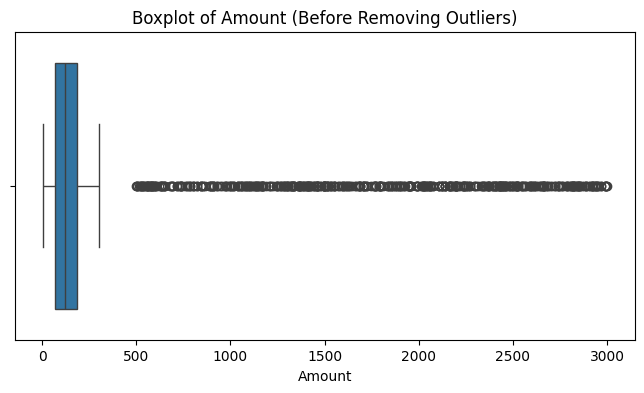

Original dataset size: 5000
Cleaned dataset size: 4493


In [5]:
# We will focus on the 'Amount' column for outlier detection
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Visualizing outliers before removal
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Amount'])
plt.title('Boxplot of Amount (Before Removing Outliers)')
plt.show()

# Filtering the data to remove outliers
df_cleaned = df[(df['Amount'] >= lower_bound) & (df['Amount'] <= upper_bound)].copy()

print(f"Original dataset size: {len(df)}")
print(f"Cleaned dataset size: {len(df_cleaned)}")

In [6]:
# Initialize scalers
min_max_scaler = MinMaxScaler()
z_score_scaler = StandardScaler()

# Columns to be scaled
cols_to_scale = ['Age', 'Amount', 'ItemRating', 'DiscountApplied(%)', 'PreviousPurchases']

# Apply Min-Max Scaling (Normalizes data to a range [0, 1])
df_cleaned['Amount_MinMax'] = min_max_scaler.fit_transform(df_cleaned[['Amount']])

# Apply Z-score Normalization (Standardization: Mean=0, Std=1)
df_cleaned['Amount_Zscore'] = z_score_scaler.fit_transform(df_cleaned[['Amount']])

# Display results
df_cleaned[['Amount', 'Amount_MinMax', 'Amount_Zscore']].head()

,Amount,Amount_MinMax,Amount_Zscore
0,115.50,0.374457,-0.039720
1,103.43,0.333526,-0.233624
2,35.45,0.102991,-1.325719
3,153.31,0.502679,0.567696
4,151.43,0.496304,0.537494


Explained Variance by PC1: 35.62%
Explained Variance by PC2: 20.20%


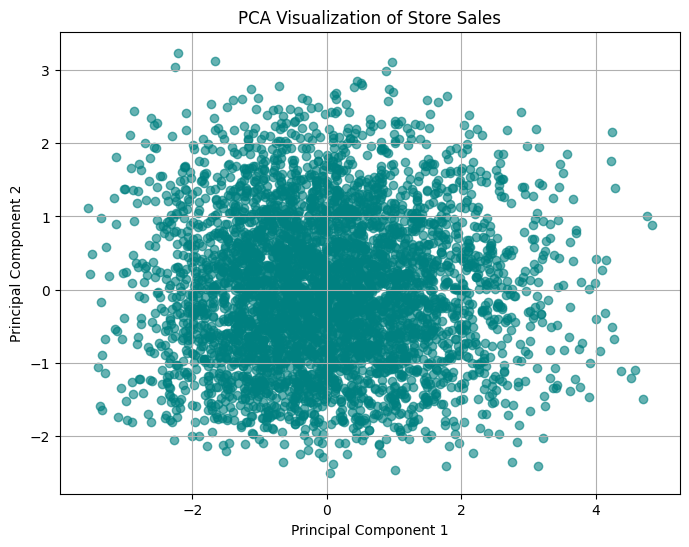

In [7]:
# Prepare data for PCA (using the 5 numerical features)
pca_features = df_cleaned[cols_to_scale]

# Step 1: Standardize the features before PCA (Requirement for PCA)
features_standardized = z_score_scaler.fit_transform(pca_features)

# Step 2: Apply PCA
pca = PCA(n_components=2) # Reducing to 2 dimensions
pca_results = pca.fit_transform(features_standardized)

# Step 3: Interpret Explained Variance
variance_ratio = pca.explained_variance_ratio_
print(f"Explained Variance by PC1: {variance_ratio[0]*100:.2f}%")
print(f"Explained Variance by PC2: {variance_ratio[1]*100:.2f}%")

# Step 4: Visualization
plt.figure(figsize=(8, 6))
plt.scatter(pca_results[:, 0], pca_results[:, 1], alpha=0.6, c='teal')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Visualization of Store Sales')
plt.grid(True)
plt.show()